<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 8</h3>
    <h3>Ejercicio 2</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p>Asistentes: Sebastián Calcagno<p>
</div>

Ejercicio Time-GPT (modelo de forecasting desarrollado por Nixtla)

_IA generativa para series temporales_

Aca vamos a :

- Construir una serie temporal desde datos reales de peajes
- Limpiar y estructurar la serie
- Completar datos faltantes
- Detectar anomalias
- Hacer forecasting
- evaluar el modelo
- usar variables exógenas

# Primera parte, ejercicio para presentarles

## Configuraciones iniciales

In [ ]:
!pip install nixtla

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from nixtla import NixtlaClient
from datetime import datetime

In [ ]:
#  Aca se conecta con los servidores de Nixtla para que te dejen usar sus modelos de prediccion

nixtla_client = NixtlaClient(

    api_key = 'nixak-h8iV80neQevJ6Zea6Vvw5QtyhIK6ADThKjuvDgp8jVZJiqlnO8C9PyKydKrMxRokzGynSddzUG30T4rc'
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd


ruta_csv = '/content/drive/My Drive/Colab Notebooks/analisis_de_series_temporales/Clase8/DISTANCIA 2024/datasetmeses01_03_2023.csv'
df = pd.read_csv(ruta_csv, encoding='latin1')

df_backup = df.copy()

df.head()

Mounted at /content/drive


,MesMesAño,Hora HH,Cat Cobrada,ID Peaje,Observacion,Sentido,Tipo Cobro,Pasos,Unnamed: 8,Unnamed: 9
0,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago,Centro,Mercado Pago,1.0,NaN,NaN
1,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago,Provincia,Mercado Pago,10.0,NaN,NaN
2,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago OCR,Centro,Mercado Pago,3.0,NaN,NaN
3,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago OCR,Provincia,Mercado Pago,3.0,NaN,NaN
4,1/1/2023,12:00:00 AM,Auto,ALB,Tag - PosPago,Centro,Tag,4.0,NaN,NaN


In [ ]:
df_backup['fecha'] = pd.to_datetime(df_backup['MesMesAño'], format='%d/%m/%Y')
df_backup['hora'] = pd.to_datetime(df_backup['Hora HH'], format='%I:%M:%S %p').dt.time

df_backup['fecha_hora'] = df_backup.apply(lambda row: datetime.combine(row['fecha'], row['hora']), axis=1)

df_backup = df_backup.drop(columns=['Unnamed: 8', 'Unnamed: 9'])

In [ ]:
df_backup.dtypes

,0
MesMesAño,object
Hora HH,object
Cat Cobrada,object
ID Peaje,object
Observacion,object
Sentido,object
Tipo Cobro,object
Pasos,float64
fecha,datetime64[ns]
hora,object


In [ ]:
df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'])

In [ ]:
df.tail()

,MesMesAño,Hora HH,Cat Cobrada,ID Peaje,Observacion,Sentido,Tipo Cobro,Pasos
798049,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB1,Violación - Normal,Provincia,Violación,1.0
798050,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago,Centro,Tag,2.0
798051,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago OCR,Centro,Tag,3.0
798052,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago,Centro,Tag,13.0
798053,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago OCR,Centro,Tag,4.0


In [ ]:
# Filtrar por la inicial ALB en la columna "ID Peaje"
df_filtrado = df[df["ID Peaje"] == 'ALB']

In [ ]:
# Filtrar sentido al centro
df_filtrado = df[df["Sentido"] == 'Centro']

In [ ]:
df_filtrado.dtypes

,0
MesMesAño,object
Hora HH,object
Cat Cobrada,object
ID Peaje,object
Observacion,object
Sentido,object
Tipo Cobro,object
Pasos,float64


In [ ]:
'''
Aqui opera las columnas de fecha para que queden en el formato correcto

'''

df_filtrado['fecha'] = pd.to_datetime(df_filtrado['MesMesAño'], format='%d/%m/%Y')
df_filtrado['hora'] = pd.to_datetime(df_filtrado['Hora HH'], format='%I:%M:%S %p').dt.time
#mezcla
df_filtrado['fecha_hora'] = df_filtrado.apply(lambda row: datetime.combine(row['fecha'], row['hora']), axis=1)

/tmp/ipykernel_1945/8532088.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['fecha'] = pd.to_datetime(df_filtrado['MesMesAño'], format='%d/%m/%Y')
/tmp/ipykernel_1945/8532088.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['hora'] = pd.to_datetime(df_filtrado['Hora HH'], format='%I:%M:%S %p').dt.time
/tmp/ipykernel_1945/8532088.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

In [ ]:
df_filtrado.tail(5)

,MesMesAño,Hora HH,Cat Cobrada,ID Peaje,Observacion,Sentido,Tipo Cobro,Pasos,fecha,hora,fecha_hora
798045,31/3/2023,11:00:00 PM,Pesados 6 Ejes,ILP,Tag - PosPago OCR,Centro,Tag,4.0,2023-03-31,23:00:00,2023-03-31 23:00:00
798050,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago,Centro,Tag,2.0,2023-03-31,23:00:00,2023-03-31 23:00:00
798051,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago OCR,Centro,Tag,3.0,2023-03-31,23:00:00,2023-03-31 23:00:00
798052,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago,Centro,Tag,13.0,2023-03-31,23:00:00,2023-03-31 23:00:00
798053,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago OCR,Centro,Tag,4.0,2023-03-31,23:00:00,2023-03-31 23:00:00


In [ ]:
df_filtrado['solo_fecha'] = df_filtrado['fecha_hora']
df_agrupado = df_filtrado.groupby('solo_fecha')['Pasos'].sum().reset_index()
df_agrupado.rename(columns={'Pasos': 'total_pasos'}, inplace=True)

print(df_agrupado.head())

           solo_fecha  total_pasos
0 2023-01-01 00:00:00    25297.287
1 2023-01-01 01:00:00     1660.000
2 2023-01-01 02:00:00     1302.000
3 2023-01-01 03:00:00     1466.000
4 2023-01-01 04:00:00     2758.000


/tmp/ipykernel_1945/4286057069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['solo_fecha'] = df_filtrado['fecha_hora']


In [ ]:
df_agrupado.head(5)

,solo_fecha,total_pasos
0,2023-01-01 00:00:00,25297.287
1,2023-01-01 01:00:00,1660.000
2,2023-01-01 02:00:00,1302.000
3,2023-01-01 03:00:00,1466.000
4,2023-01-01 04:00:00,2758.000


## Detección de anomalías y trabajo para completar los campos sin dato

La detección de anomalías implica hacer predicciones y generar un intervalo de confianza del 99%. Si un punto observado queda fuera de ese intervalo, se trata de una anomalía.*texto en cursiva*

https://docs.nixtla.io/docs/tutorials-missing_values

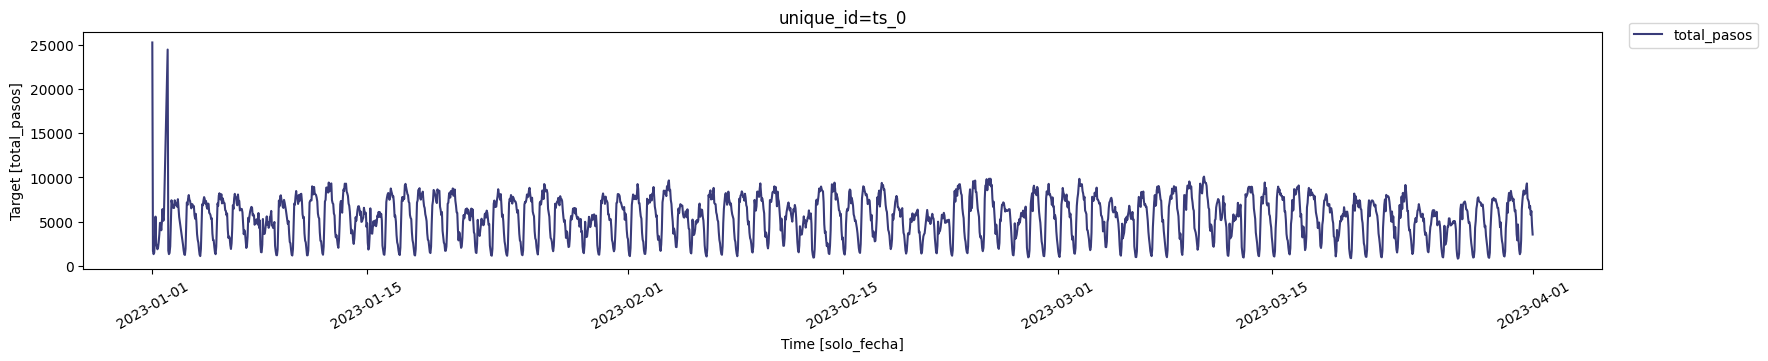

In [ ]:
nixtla_client.plot(df_agrupado,
                   time_col='solo_fecha',
                   target_col='total_pasos',
                   max_insample_length= 3000
                   )

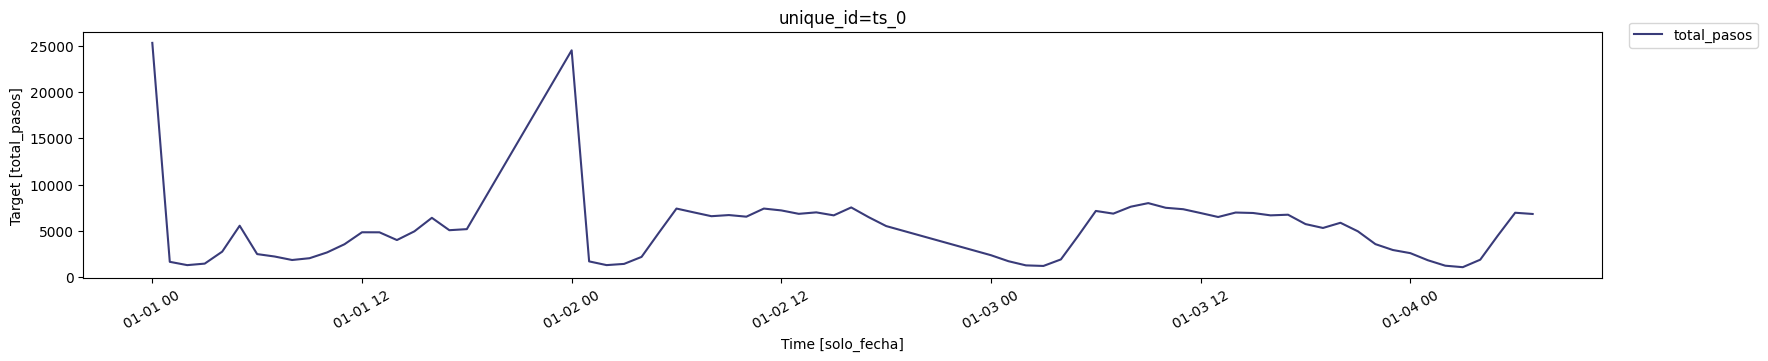

In [ ]:
# Filtrar las primeras 70 filas y las grafica
df_primero_70 = df_agrupado.head(70)


nixtla_client.plot(df_primero_70,
                   time_col='solo_fecha',
                   target_col='total_pasos',
                   engine='matplotlib')


In [ ]:
# Ver las primeras 20 filas
print(df_primero_70.head(40))

# Ver las últimas 20 filas
print(df_primero_70.tail(20))

            solo_fecha  total_pasos
0  2023-01-01 00:00:00    25297.287
1  2023-01-01 01:00:00     1660.000
2  2023-01-01 02:00:00     1302.000
3  2023-01-01 03:00:00     1466.000
4  2023-01-01 04:00:00     2758.000
5  2023-01-01 05:00:00     5557.000
6  2023-01-01 06:00:00     2494.000
7  2023-01-01 07:00:00     2233.000
8  2023-01-01 08:00:00     1856.000
9  2023-01-01 09:00:00     2050.000
10 2023-01-01 10:00:00     2673.000
11 2023-01-01 11:00:00     3559.000
12 2023-01-01 12:00:00     4850.000
13 2023-01-01 13:00:00     4845.000
14 2023-01-01 14:00:00     4010.000
15 2023-01-01 15:00:00     4951.000
16 2023-01-01 16:00:00     6410.000
17 2023-01-01 17:00:00     5073.344
18 2023-01-01 18:00:00     5188.703
19 2023-01-02 00:00:00    24494.012
20 2023-01-02 01:00:00     1706.000
21 2023-01-02 02:00:00     1304.000
22 2023-01-02 03:00:00     1435.000
23 2023-01-02 04:00:00     2190.000
24 2023-01-02 05:00:00     4823.000
25 2023-01-02 06:00:00     7409.869
26 2023-01-02 07:00:00     6

In [ ]:
df_agrupado.rename(columns={'solo_fecha': 'ds', 'total_pasos': 'y'}, inplace=True)
df_agrupado.head()

,ds,y
0,2023-01-01 00:00:00,25297.287
1,2023-01-01 01:00:00,1660.000
2,2023-01-01 02:00:00,1302.000
3,2023-01-01 03:00:00,1466.000
4,2023-01-01 04:00:00,2758.000


In [ ]:
df_agrupado_2=df_agrupado.copy()

In [ ]:
df_agrupado['unique_id'] = 'id1'
df_agrupado = df_agrupado[['unique_id', 'ds', 'y']]

In [ ]:
from utilsforecast.preprocessing import fill_gaps


In [ ]:
print('Number of rows before filling gaps:', len(df_agrupado))
df_agrupado_complete = fill_gaps(df_agrupado, freq='H')
print('Number of rows after filling gaps:', len(df_agrupado_complete))

# Inserta esas filas nuevas con valores NaN en la columna y (total_pasos).

Number of rows before filling gaps: 2150
Number of rows after filling gaps: 2160


/usr/local/lib/python3.12/dist-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


In [ ]:
# Filtrar las primeras 70 filas
df_agrupado_complete_primero_70 = df_agrupado_complete.head(70)

print(df_agrupado_complete_primero_70.head(40))


print(df_agrupado_complete_primero_70.tail(20))

   unique_id                  ds          y
0        id1 2023-01-01 00:00:00  25297.287
1        id1 2023-01-01 01:00:00   1660.000
2        id1 2023-01-01 02:00:00   1302.000
3        id1 2023-01-01 03:00:00   1466.000
4        id1 2023-01-01 04:00:00   2758.000
5        id1 2023-01-01 05:00:00   5557.000
6        id1 2023-01-01 06:00:00   2494.000
7        id1 2023-01-01 07:00:00   2233.000
8        id1 2023-01-01 08:00:00   1856.000
9        id1 2023-01-01 09:00:00   2050.000
10       id1 2023-01-01 10:00:00   2673.000
11       id1 2023-01-01 11:00:00   3559.000
12       id1 2023-01-01 12:00:00   4850.000
13       id1 2023-01-01 13:00:00   4845.000
14       id1 2023-01-01 14:00:00   4010.000
15       id1 2023-01-01 15:00:00   4951.000
16       id1 2023-01-01 16:00:00   6410.000
17       id1 2023-01-01 17:00:00   5073.344
18       id1 2023-01-01 18:00:00   5188.703
19       id1 2023-01-01 19:00:00        NaN
20       id1 2023-01-01 20:00:00        NaN
21       id1 2023-01-01 21:00:00

In [ ]:
# Ver los NaN
campos_nan = df_agrupado_complete[df_agrupado_complete['y'].isna()]
print(campos_nan)

   unique_id                  ds   y
19       id1 2023-01-01 19:00:00 NaN
20       id1 2023-01-01 20:00:00 NaN
21       id1 2023-01-01 21:00:00 NaN
22       id1 2023-01-01 22:00:00 NaN
23       id1 2023-01-01 23:00:00 NaN
43       id1 2023-01-02 19:00:00 NaN
44       id1 2023-01-02 20:00:00 NaN
45       id1 2023-01-02 21:00:00 NaN
46       id1 2023-01-02 22:00:00 NaN
47       id1 2023-01-02 23:00:00 NaN


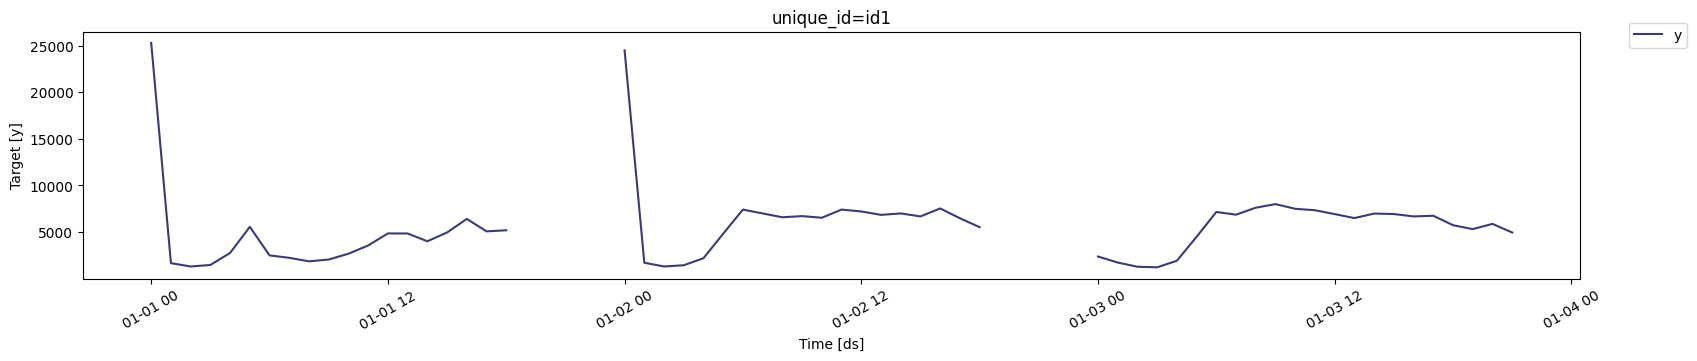

In [ ]:
# Filtrar las primeras 70 filas

nixtla_client.plot(df_agrupado_complete_primero_70,
                   time_col='ds',
                   target_col='y',
                   engine='matplotlib')

In [ ]:
# Llenamos con la mediana de la columna y
df_agrupado_complete['y'].fillna(df_agrupado_complete['y'].median(), inplace=True)

# Otras formas

# df_agrupado_complete['y'].fillna(method='ffill', inplace=True)  --> Con el último valor conocido
# df_agrupado_complete['y'].fillna(df_agrupado_complete['y'].mean(), inplace=True)  --> Con la media

/tmp/ipykernel_1945/937505791.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_agrupado_complete['y'].fillna(df_agrupado_complete['y'].median(), inplace=True)


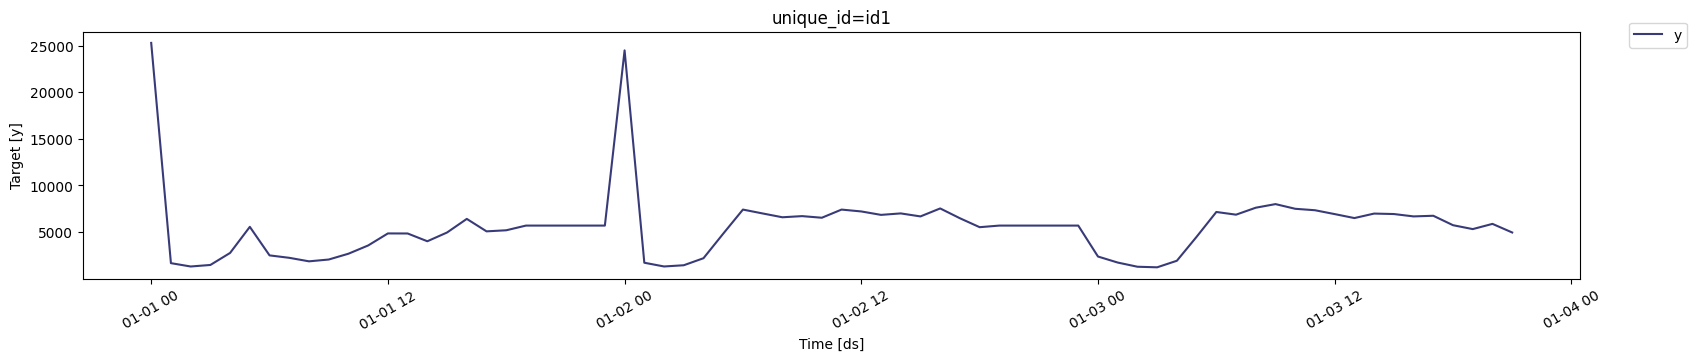

In [ ]:
# Filtrar las primeras 70 filas
df_agrupado_complete_primero_70_2 = df_agrupado_complete.head(70)

# Filtrar las primeras 70 filas

nixtla_client.plot(df_agrupado_complete_primero_70_2,
                   time_col='ds',
                   target_col='y',
                   engine='matplotlib')

In [ ]:
help(nixtla_client.detect_anomalies)

Help on method detect_anomalies in module nixtla.nixtla_client:

detect_anomalies(df: ~AnyDFType, freq: Union[str, int, pandas._libs.tslibs.offsets.BaseOffset, NoneType] = None, id_col: str = 'unique_id', time_col: str = 'ds', target_col: str = 'y', level: Union[int, float] = 99, finetuned_model_id: Optional[str] = None, clean_ex_first: bool = True, validate_api_key: bool = False, date_features: Union[bool, list[str]] = False, date_features_to_one_hot: Union[bool, list[str]] = False, model: str = 'timegpt-1', num_partitions: Optional[Annotated[int, Gt(gt=0)]] = None, multivariate: bool = False) -> ~AnyDFType method of nixtla.nixtla_client.NixtlaClient instance
    Detect anomalies in your time series using TimeGPT.

    Args:
        df (pandas or polars DataFrame): The DataFrame on which the
            function will operate. Expected to contain at least the
            following columns:
            - time_col:
                Column name in `df` that contains the time indices of the

https://docs.nixtla.io/docs/capabilities-anomaly-detection-anomaly_detection

La detección de anomalías implica hacer predicciones y generar un intervalo de confianza del 99% ( por ejemplo ). Si un punto observado queda fuera de ese intervalo, se trata de una anomalía.

/usr/local/lib/python3.12/dist-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


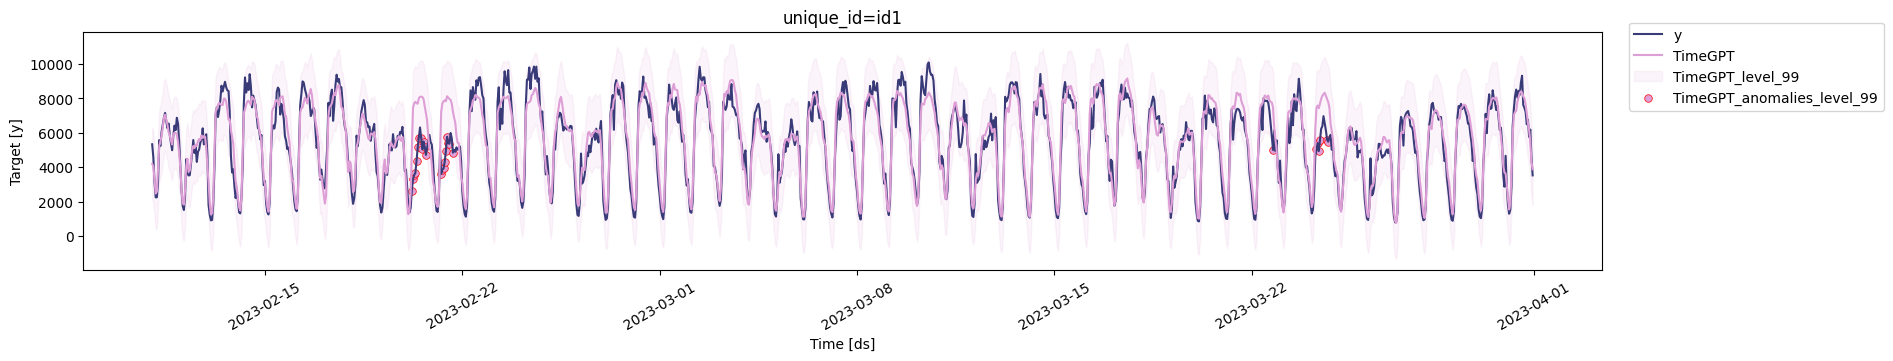

In [ ]:
# Deteccion de anomalias
anomalies_df = nixtla_client.detect_anomalies(
    df_agrupado_complete,
    time_col='ds',
    target_col='y',
    freq='H',
    clean_ex_first = False,           # Usa la serie tal como está. Los outliers pueden detectarse como anomalias.
    model='timegpt-1-long-horizon',   # Define qué modelo usar para detectar anomalias.
    level=99  # marca como anomalía todo lo que cae fuera del rango esperado con esa confianza
)

# Plotear anomalias
nixtla_client.plot(
    df_agrupado_complete,
    anomalies_df,
    time_col='ds',
    target_col='y'
)

In [ ]:
anomalies_df[anomalies_df['anomaly'] == True].sort_values(by='ds')

,unique_id,ds,y,TimeGPT,TimeGPT-hi-99,TimeGPT-lo-99,anomaly
221,id1,2023-02-20 05:00:00,2634.000,4944.3076,7033.8980,2854.7173,True
222,id1,2023-02-20 06:00:00,3311.000,7439.7280,9529.3180,5350.1377,True
223,id1,2023-02-20 07:00:00,3544.000,7713.2173,9802.8080,5623.6270,True
224,id1,2023-02-20 08:00:00,3669.000,7804.4750,9894.0650,5714.8850,True
225,id1,2023-02-20 09:00:00,4356.000,7723.3857,9812.9770,5633.7954,True
226,id1,2023-02-20 10:00:00,5147.000,7693.7695,9783.3600,5604.1790,True
227,id1,2023-02-20 11:00:00,5716.000,8013.1035,10102.6940,5923.5130,True
229,id1,2023-02-20 13:00:00,5692.000,8101.7056,10191.2960,6012.1150,True
230,id1,2023-02-20 14:00:00,5041.000,8082.8047,10172.3955,5993.2144,True
231,id1,2023-02-20 15:00:00,5492.000,7948.0530,10037.6440,5858.4630,True


## Proyeccion simple

In [ ]:
print('Number of rows before filling gaps:', len(df_agrupado))
df_agrupado_proyeccion_simple = fill_gaps(df_agrupado, freq='H')
print('Number of rows after filling gaps:', len(df_agrupado_proyeccion_simple))

Number of rows before filling gaps: 2150
Number of rows after filling gaps: 2160


/usr/local/lib/python3.12/dist-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)


In [ ]:
missing_values = df_agrupado_proyeccion_simple.isnull().sum()
print(missing_values)

unique_id     0
ds            0
y            10
dtype: int64


In [ ]:
rows_with_missing = df_agrupado_proyeccion_simple[df_agrupado_proyeccion_simple.isnull().any(axis=1)]
print(rows_with_missing)

   unique_id                  ds   y
19       id1 2023-01-01 19:00:00 NaN
20       id1 2023-01-01 20:00:00 NaN
21       id1 2023-01-01 21:00:00 NaN
22       id1 2023-01-01 22:00:00 NaN
23       id1 2023-01-01 23:00:00 NaN
43       id1 2023-01-02 19:00:00 NaN
44       id1 2023-01-02 20:00:00 NaN
45       id1 2023-01-02 21:00:00 NaN
46       id1 2023-01-02 22:00:00 NaN
47       id1 2023-01-02 23:00:00 NaN


In [ ]:
df_agrupado_proyeccion_simple = df_agrupado_proyeccion_simple.iloc[48:].reset_index(drop=True)

In [ ]:
rows_with_missing = df_agrupado_proyeccion_simple[df_agrupado_proyeccion_simple.isnull().any(axis=1)]
print(rows_with_missing)

Empty DataFrame
Columns: [unique_id, ds, y]
Index: []


In [ ]:
df_agrupado_proyeccion_simple.head(5)

,unique_id,ds,y
0,id1,2023-01-03 00:00:00,2372.0
1,id1,2023-01-03 01:00:00,1725.0
2,id1,2023-01-03 02:00:00,1276.0
3,id1,2023-01-03 03:00:00,1214.0
4,id1,2023-01-03 04:00:00,1918.0


In [ ]:
# Definir cantidad de observaciones para test
n_test = 24


df_train = df_agrupado_proyeccion_simple.iloc[:-n_test].reset_index(drop=True)
df_test = df_agrupado_proyeccion_simple.iloc[-n_test:].reset_index(drop=True)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nTrain:")
print(df_train.head())

print("\nTest:")
print(df_test.head())


Train shape: (2088, 3)
Test shape: (24, 3)

Train:
  unique_id                  ds       y
0       id1 2023-01-03 00:00:00  2372.0
1       id1 2023-01-03 01:00:00  1725.0
2       id1 2023-01-03 02:00:00  1276.0
3       id1 2023-01-03 03:00:00  1214.0
4       id1 2023-01-03 04:00:00  1918.0

Test:
  unique_id                  ds       y
0       id1 2023-03-31 00:00:00  4666.0
1       id1 2023-03-31 01:00:00  2878.0
2       id1 2023-03-31 02:00:00  1772.0
3       id1 2023-03-31 03:00:00  1293.0
4       id1 2023-03-31 04:00:00  1521.0


/usr/local/lib/python3.12/dist-packages/utilsforecast/preprocessing.py:123: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  offset = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


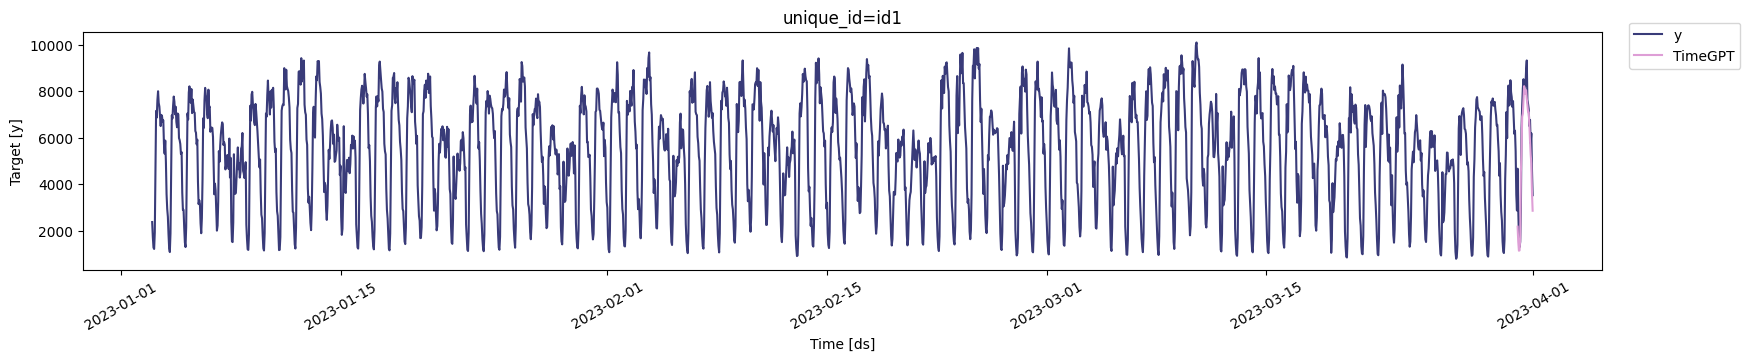

In [ ]:
# Forecast
forecast_df = nixtla_client.forecast(
    df=df_train,    # df_agrupado_proyeccion_simple
    h=24,
    time_col='ds',
    target_col="y",
    freq='H'

)
'''
# Plot predictions
nixtla_client.plot(
    df=df_train,   # df_agrupado_proyeccion_simple
    forecasts_df=forecast_df,
    time_col='ds',
    target_col='y'
)
'''

nixtla_client.plot(
    df=pd.concat([df_train, df_test]),
    forecasts_df=forecast_df,
    time_col='ds',
    target_col='y'
)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_true = df_test['y'].values
y_pred = forecast_df['TimeGPT'].values


mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"MAE  (Error Absoluto Medio):     {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.2f}")
print(f"MAPE (Error Porcentual Medio):   {mape:.2f}%")



MAE  (Error Absoluto Medio):     766.39
RMSE (Raíz del Error Cuadrático): 967.93
MAPE (Error Porcentual Medio):   16.33%


## Agregar variables exógenas a la proyeccion


Para modelar con características exógenas, tienes dos opciones:

1. Usar variables exogenas historicas: Incluye estas variables en el dataFrame que pasas al metodo de pronostico. Esto significa que las variables que ya has observado en el pasado se utilizan como informacion adicional para mejorar el modelo de pronostico.

2. Usar variables exogenas futuras: Incluye estas variables en el dataFrame que pasas al metodo de pronostico y proporciona los valores futuros de estas caracteristicas exogenas a lo largo del horizonte de pronóstico utilizando el parametro `X_df`. Esto implica que debes tener los valores previstos de estas variables para el periodo que estás tratando de predecir, lo cual puede ayudar a obtener pronósticos más precisos.

1. Variables exógenas históricas


In [ ]:
# Hago copia para trabajar con df_exogenas_hist
df_exogenas_hist=df_backup.copy()

In [ ]:
# filtro por ALB , ILL y AVE ( ILL y AVE las uso como exogenas)
df_exogenas_hist = df_exogenas_hist[df_exogenas_hist["ID Peaje"].isin([ 'ILL', 'AVE'])]

# Filtrar sentido al centro
df_exogenas_hist = df_exogenas_hist[df_exogenas_hist["Sentido"] == 'Centro']

In [ ]:
# Filtrar los datos para cada valor en ID Peaje
df_ILL = df_exogenas_hist[df_exogenas_hist["ID Peaje"] == 'ILL']
df_AVE = df_exogenas_hist[df_exogenas_hist["ID Peaje"] == 'AVE']
# df_ALB = df_exogenas_hist[df_exogenas_hist["ID Peaje"] == 'ALB']

In [ ]:
df_ALB_agrupado=df_agrupado_proyeccion_simple.copy()

In [ ]:
df_ALB_agrupado = df_ALB_agrupado.drop(columns=['unique_id'])

In [ ]:
df_ALB_agrupado = df_ALB_agrupado.rename(columns={
    'ds': 'solo_fecha',
    'y': 'total_pasos_alb'
})

In [ ]:
len(df_ALB_agrupado)

2112

In [ ]:
# Trabajo con el dataset de ill

df_ILL['solo_fecha'] = df_ILL['fecha_hora']

df_ILL_agrupado = df_ILL.groupby('solo_fecha')['Pasos'].sum().reset_index()


df_ILL_agrupado.rename(columns={'Pasos': 'total_pasos_ill'}, inplace=True)

print(df_ILL_agrupado.head())

           solo_fecha  total_pasos_ill
0 2023-01-01 00:00:00           7471.0
1 2023-01-01 01:00:00            362.0
2 2023-01-01 02:00:00            330.0
3 2023-01-01 03:00:00            340.0
4 2023-01-01 04:00:00            651.0


/tmp/ipykernel_1945/1429388557.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ILL['solo_fecha'] = df_ILL['fecha_hora']


In [ ]:
len(df_ILL_agrupado)

2150

In [ ]:
# Trabajo con el dataset de ave


df_AVE['solo_fecha'] = df_AVE['fecha_hora']# .dt.date

df_AVE_agrupado = df_AVE.groupby('solo_fecha')['Pasos'].sum().reset_index()

df_AVE_agrupado.rename(columns={'Pasos': 'total_pasos_ave'}, inplace=True)

print(df_AVE_agrupado.head())

           solo_fecha  total_pasos_ave
0 2023-01-01 00:00:00         8879.899
1 2023-01-01 01:00:00          561.000
2 2023-01-01 02:00:00          355.000
3 2023-01-01 03:00:00          476.000
4 2023-01-01 04:00:00         1082.000


/tmp/ipykernel_1945/2772926885.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_AVE['solo_fecha'] = df_AVE['fecha_hora']# .dt.date


In [ ]:
len(df_AVE_agrupado)

2150

In [ ]:
# Realizar un merge en la columna de fecha
df_combined = df_ILL_agrupado.merge(df_AVE_agrupado, on='solo_fecha', how='outer').merge(df_ALB_agrupado, on='solo_fecha', how='outer')


In [ ]:
df_combined = df_combined.iloc[38:].reset_index(drop=True)

In [ ]:
df_combined

,solo_fecha,total_pasos_ill,total_pasos_ave,total_pasos_alb
0,2023-01-03 00:00:00,475.000,755.000,2372.000
1,2023-01-03 01:00:00,366.000,525.000,1725.000
2,2023-01-03 02:00:00,215.000,331.000,1276.000
3,2023-01-03 03:00:00,197.000,355.000,1214.000
4,2023-01-03 04:00:00,307.000,658.000,1918.000
...,...,...,...,...
2107,2023-03-31 19:00:00,2561.000,1955.075,6762.081
2108,2023-03-31 20:00:00,1650.063,1959.960,5759.058
2109,2023-03-31 21:00:00,2115.000,1500.424,6188.424
2110,2023-03-31 22:00:00,1180.000,1657.000,4582.000


In [ ]:
# Definir cantidad de observaciones para test
n_test = 24


df_train = df_combined.iloc[:-n_test].reset_index(drop=True)
df_test = df_combined.iloc[-n_test:].reset_index(drop=True)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nTrain:")
print(df_train.head())

print("\nTest:")
print(df_test.head())


Train shape: (2088, 4)
Test shape: (24, 4)

Train:
           solo_fecha  total_pasos_ill  total_pasos_ave  total_pasos_alb
0 2023-01-03 00:00:00            475.0            755.0           2372.0
1 2023-01-03 01:00:00            366.0            525.0           1725.0
2 2023-01-03 02:00:00            215.0            331.0           1276.0
3 2023-01-03 03:00:00            197.0            355.0           1214.0
4 2023-01-03 04:00:00            307.0            658.0           1918.0

Test:
           solo_fecha  total_pasos_ill  total_pasos_ave  total_pasos_alb
0 2023-03-31 00:00:00           2067.0           1228.0           4666.0
1 2023-03-31 01:00:00            908.0           1026.0           2878.0
2 2023-03-31 02:00:00            512.0            638.0           1772.0
3 2023-03-31 03:00:00            293.0            482.0           1293.0
4 2023-03-31 04:00:00            301.0            558.0           1521.0


In [ ]:
exog_cols = ['total_pasos_ill', 'total_pasos_ave']

nan_count = df_train[exog_cols].isna().sum()

print("Cantidad de NaNs por variable exógena:")
print(nan_count)


Cantidad de NaNs por variable exógena:
total_pasos_ill    0
total_pasos_ave    0
dtype: int64


In [ ]:
df_train.tail()

,solo_fecha,total_pasos_ill,total_pasos_ave,total_pasos_alb
2083,2023-03-30 19:00:00,1633.247,1583.599,6161.846
2084,2023-03-30 20:00:00,2305.000,1347.243,6300.243
2085,2023-03-30 21:00:00,1470.000,1899.000,5420.000
2086,2023-03-30 22:00:00,986.000,1111.000,3543.000
2087,2023-03-30 23:00:00,790.000,922.000,2868.000


In [ ]:
df_test.head()

,solo_fecha,total_pasos_ill,total_pasos_ave,total_pasos_alb
0,2023-03-31 00:00:00,2067.0,1228.0,4666.0
1,2023-03-31 01:00:00,908.0,1026.0,2878.0
2,2023-03-31 02:00:00,512.0,638.0,1772.0
3,2023-03-31 03:00:00,293.0,482.0,1293.0
4,2023-03-31 04:00:00,301.0,558.0,1521.0


In [ ]:
# proyeccion
forecast_df = nixtla_client.forecast(
    df=df_train,
    h=24,
    target_col='total_pasos_alb',
    time_col='solo_fecha',
    hist_exog_list=['total_pasos_ill', 'total_pasos_ave']
)

In [ ]:
df_test.head(5)

,solo_fecha,total_pasos_ill,total_pasos_ave,total_pasos_alb
0,2023-03-31 00:00:00,2067.0,1228.0,4666.0
1,2023-03-31 01:00:00,908.0,1026.0,2878.0
2,2023-03-31 02:00:00,512.0,638.0,1772.0
3,2023-03-31 03:00:00,293.0,482.0,1293.0
4,2023-03-31 04:00:00,301.0,558.0,1521.0


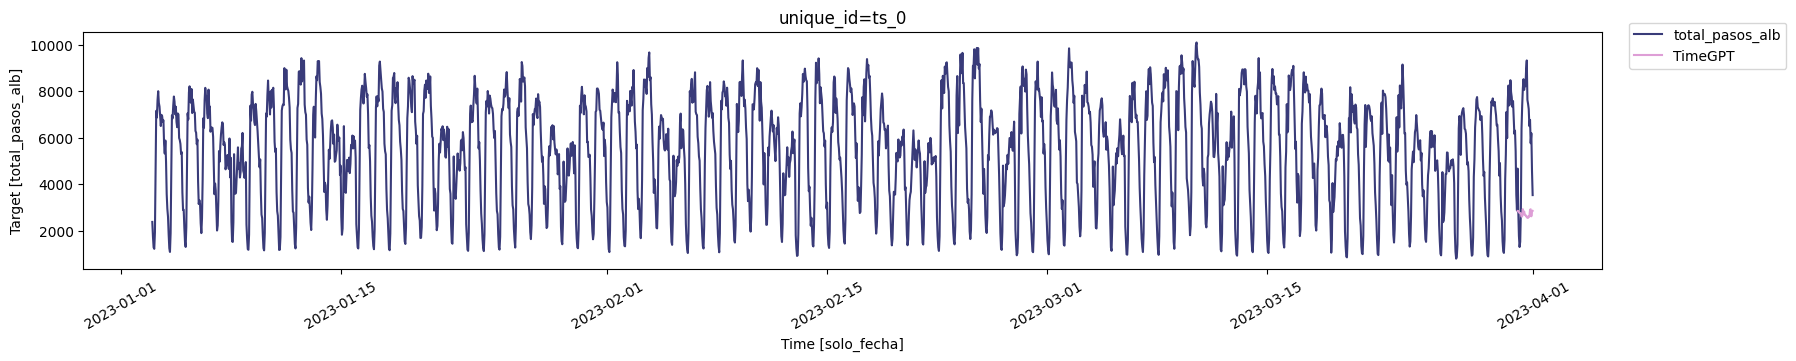

In [ ]:
# Grafico

nixtla_client.plot(
    df=pd.concat([df_train, df_test]),
    forecasts_df=forecast_df,
    time_col='solo_fecha',
    target_col='total_pasos_alb'
)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

y_true = df_test['total_pasos_alb'].values
y_pred = forecast_df['TimeGPT'].values


mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"MAE  (Error Absoluto Medio):     {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático): {rmse:.2f}")
print(f"MAPE (Error Porcentual Medio):   {mape:.2f}%")


MAE  (Error Absoluto Medio):     3585.28
RMSE (Raíz del Error Cuadrático): 4120.86
MAPE (Error Porcentual Medio):   57.30%


La inclusion de variables exogenas no siempre garantiza mejoras. En este caso probablemente introdujeron mas complejidad que valor predictivo neto. Podrian como tarea probar con rezagos o incluso agregar otras variables al modelo

2. Variables exógenas futuras


In [ ]:
ruta_csv = '/content/drive/My Drive/Colab Notebooks/analisis_de_series_temporales/Clase8/DISTANCIA 2024/Var_Ex_Fut_Prueba.csv'
Var_Ex_Fut_Prueba = pd.read_csv(ruta_csv, encoding='latin1')

Var_Ex_Fut_Prueba

,MesMesAño,Hora HH,total_pasos_ave,total_pasos_ill
0,1/4/2023,12:00:00 AM,4629.646652,344.240379
1,1/4/2023,1:00:00 AM,5589.791760,379.669153
2,1/4/2023,2:00:00 AM,5261.008088,377.829441
3,1/4/2023,3:00:00 AM,5070.107642,362.069392
4,1/4/2023,4:00:00 AM,4738.966444,384.126381
5,1/4/2023,5:00:00 AM,4255.541490,361.751130
6,1/4/2023,6:00:00 AM,3987.971656,329.731853
7,1/4/2023,7:00:00 AM,3616.693356,406.332720
8,1/4/2023,8:00:00 AM,3704.431580,300.018969
9,1/4/2023,9:00:00 AM,2896.010180,314.040424


In [ ]:
# formato Datetime
Var_Ex_Fut_Prueba['fecha'] = pd.to_datetime(Var_Ex_Fut_Prueba['MesMesAño'], format='%d/%m/%Y')
Var_Ex_Fut_Prueba['hora'] = pd.to_datetime(Var_Ex_Fut_Prueba['Hora HH'], format='%I:%M:%S %p').dt.time
#mezcla
Var_Ex_Fut_Prueba['solo_fecha'] = Var_Ex_Fut_Prueba.apply(lambda row: datetime.combine(row['fecha'], row['hora']), axis=1)



Var_Ex_Fut_Prueba.dtypes

,0
MesMesAño,object
Hora HH,object
total_pasos_ave,float64
total_pasos_ill,float64
fecha,datetime64[ns]
hora,object
solo_fecha,datetime64[ns]


In [ ]:
Var_Ex_Fut_Prueba = Var_Ex_Fut_Prueba.drop(columns=['MesMesAño', 'Hora HH','fecha','hora'])

In [ ]:
Var_Ex_Fut_Prueba

,total_pasos_ave,total_pasos_ill,solo_fecha
0,4629.646652,344.240379,2023-04-01 00:00:00
1,5589.791760,379.669153,2023-04-01 01:00:00
2,5261.008088,377.829441,2023-04-01 02:00:00
3,5070.107642,362.069392,2023-04-01 03:00:00
4,4738.966444,384.126381,2023-04-01 04:00:00
5,4255.541490,361.751130,2023-04-01 05:00:00
6,3987.971656,329.731853,2023-04-01 06:00:00
7,3616.693356,406.332720,2023-04-01 07:00:00
8,3704.431580,300.018969,2023-04-01 08:00:00
9,2896.010180,314.040424,2023-04-01 09:00:00


In [ ]:
# Forecast
forecast_df = nixtla_client.forecast(
    df=df_combined,
    X_df=Var_Ex_Fut_Prueba,   # dataset de variables exógenas futuras
    h=12,
    id_col='unique_id',  # estan preparados para recibir datos en formato multiserie .  Aca hay una sola
    target_col='total_pasos_alb',
    time_col='solo_fecha'   # debe estar presente tanto en df como en X_df
)

In [ ]:
df_combined

,solo_fecha,total_pasos_ill,total_pasos_ave,total_pasos_alb
0,2023-01-03 00:00:00,475.000,755.000,2372.000
1,2023-01-03 01:00:00,366.000,525.000,1725.000
2,2023-01-03 02:00:00,215.000,331.000,1276.000
3,2023-01-03 03:00:00,197.000,355.000,1214.000
4,2023-01-03 04:00:00,307.000,658.000,1918.000
...,...,...,...,...
2107,2023-03-31 19:00:00,2561.000,1955.075,6762.081
2108,2023-03-31 20:00:00,1650.063,1959.960,5759.058
2109,2023-03-31 21:00:00,2115.000,1500.424,6188.424
2110,2023-03-31 22:00:00,1180.000,1657.000,4582.000


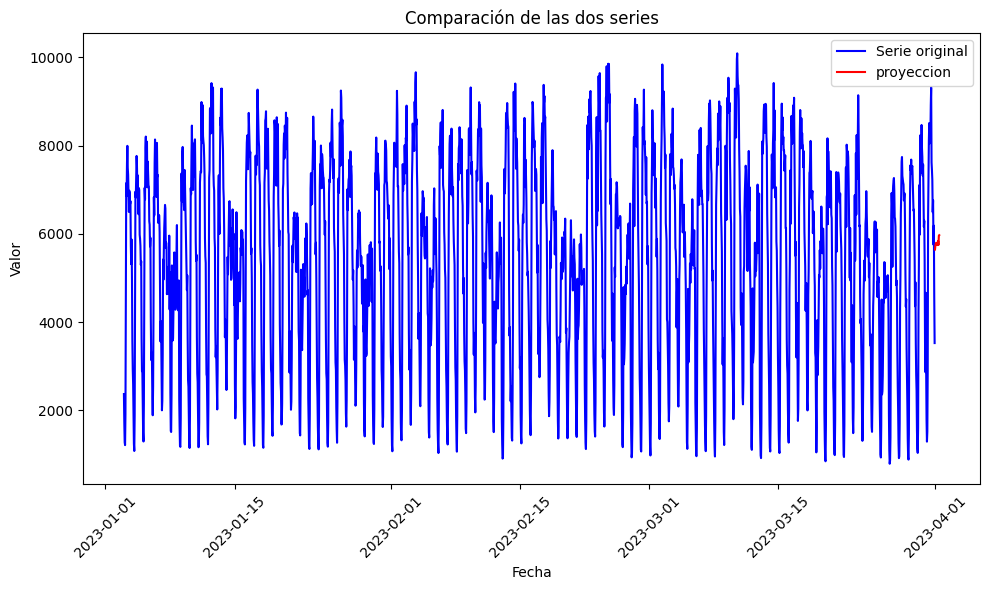

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(df_combined['solo_fecha'], df_combined['total_pasos_alb'], label='Serie original', color='blue')
plt.plot(forecast_df['solo_fecha'], forecast_df['TimeGPT'], label='proyeccion', color='red')


plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Comparación de las dos series')
plt.legend()


plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Añadir festivos y fechas especiales


In [ ]:
import pandas as pd
from nixtla import NixtlaClient
from nixtla.date_features import CountryHolidays
from nixtla.date_features import SpecialDates

In [ ]:
# Obtenga vacaciones en el país de Argentina
c_holidays = CountryHolidays(countries=['AR'])
periods = 365 * 1
dates = pd.date_range(end='2023-12-31', periods=periods)   # 2023-09-01
holidays_df = c_holidays(dates)

# Especifica tus propias fechas especiales
special_dates = SpecialDates(
    special_dates={
        'Important Dates': ['2023-01-26', '2023-02-26'],
        'Very Important Dates': ['2023-04-30', '2023-09-08', '2023-10-26']
    }
)
periods = 365 * 1
dates = pd.date_range(end='2023-12-31', periods=periods)
special_dates_df = special_dates(dates)

In [ ]:
holidays_df.loc['2023-12-25']

,2023-12-25
AR_New Year's Day,0
AR_Carnival Monday,0
AR_Carnival Tuesday,0
AR_National Day of Remembrance for Truth and Justice,0
AR_Veteran's Day and the Fallen in the Malvinas War,0
AR_Maundy Thursday,0
AR_Good Friday,0
AR_Labor Day,0
AR_May Revolution Day,0
AR_Pass to the Immortality of General Don Martín Miguel de Güemes,0


In [ ]:
special_dates_df.loc['2023-04-30']

,2023-04-30
Important Dates,0
Very Important Dates,1


In [ ]:
# Para el Forecast se agrega a el modelo
'''
forecast_df = nixtla_client.forecast(
    df=df_train,
    h=24,
    time_col='ds',
    target_col='y',
    freq='H',
    hist_exog_list=['Holiday_AR', 'Important Dates', 'Very Important Dates']  # aca se podria agregar estas variables
)
'''

"\nforecast_df = nixtla_client.forecast(\n    df=df_train,\n    h=24,\n    time_col='ds',\n    target_col='y',\n    freq='H',\n    hist_exog_list=['Holiday_AR', 'Important Dates', 'Very Important Dates']  # aca se podria agregar estas variables\n)\n"

## Agregar variables categóricas

In [ ]:

!pip install -Uqq nixtla # acualizas el paquete nixtla a su ultima version disponible

In [ ]:
#| hide
from nixtla.utils import in_colab

In [ ]:
#| hide
IN_COLAB = in_colab() # ACA te permite que tu notebook funcione bien tanto en Colab como fuera.

In [ ]:
#| hide
if not IN_COLAB:
    from nixtla.utils import colab_badge
    from dotenv import load_dotenv

In [ ]:
#| echo: false
if not IN_COLAB:
    load_dotenv()
    colab_badge('docs/capabilities/forecast/04_categorical_variables')

In [ ]:
import pandas as pd
import datetime
from nixtla import NixtlaClient
from nixtla.date_features import SpecialDates

In [ ]:
nixtla_client = NixtlaClient(
    # defaults to os.environ.get("NIXTLA_API_KEY")
    api_key = 'nixak-h8iV80neQevJ6Zea6Vvw5QtyhIK6ADThKjuvDgp8jVZJiqlnO8C9PyKydKrMxRokzGynSddzUG30T4rc'
)

In [ ]:
#| hide
if not IN_COLAB:
    nixtla_client = NixtlaClient()

In [ ]:
url='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/serie-tiempo-parques-nacionales-mensual.csv'
data = pd.read_csv(url)

In [ ]:
data.fecha = pd.to_datetime(data.indice_tiempo, dayfirst = True)
data = data.iloc[:-22]

/tmp/ipykernel_1945/2592040075.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.fecha = pd.to_datetime(data.indice_tiempo, dayfirst = True)


In [ ]:
data = data[['indice_tiempo', 'total']]

In [ ]:
data

,indice_tiempo,total
0,2008-01-01,550710
1,2008-02-01,434953
2,2008-03-01,321667
3,2008-04-01,130097
4,2008-05-01,92538
...,...,...
141,2019-10-01,358995
142,2019-11-01,404521
143,2019-12-01,436156
144,2020-01-01,779018


In [ ]:
# Create categorical variables to label Christmas and summer vacations
categories_dates = SpecialDates(
    special_dates={
        'vacaciones_navidad': [datetime.date(year, 12, 1) for year in range(2008, 2020 + 1)],
        'vacaciones_verano': [datetime.date(year, month, 1) for year in range(2008, 2020 + 1) for month in (1, 2)]
    }
)

dates = pd.date_range('2008-01-01', '2020-02-01', freq='MS')

categories_df = categories_dates(dates).reset_index(drop=True)

# Merge with the dataset
cat_df = pd.concat([data, categories_df], axis=1)

# Forecast
forecast_df = nixtla_client.forecast(
    df=cat_df,
    h=12,
    target_col='total',
    time_col='indice_tiempo'
)

In [ ]:
cat_df

,indice_tiempo,total,vacaciones_navidad,vacaciones_verano
0,2008-01-01,550710,0,1
1,2008-02-01,434953,0,1
2,2008-03-01,321667,0,0
3,2008-04-01,130097,0,0
4,2008-05-01,92538,0,0
...,...,...,...,...
141,2019-10-01,358995,0,0
142,2019-11-01,404521,0,0
143,2019-12-01,436156,1,0
144,2020-01-01,779018,0,1


In [ ]:
forecast_df

,indice_tiempo,TimeGPT
0,2020-03-01,502544.12
1,2020-04-01,402758.56
2,2020-05-01,261208.90
3,2020-06-01,264476.30
4,2020-07-01,418981.47
5,2020-08-01,341739.97
6,2020-09-01,374752.94
7,2020-10-01,431006.84
8,2020-11-01,462218.25
9,2020-12-01,492965.90


## Horizonte de prediccion largo


In [ ]:
# Forecast
forecast_df = nixtla_client.forecast(
    df=data,
    h=36,
    model='timegpt-1-long-horizon',
    time_col='indice_tiempo',
    target_col="total"
)

In [ ]:
forecast_df.tail(5)

,indice_tiempo,TimeGPT
31,2022-10-01,525263.4
32,2022-11-01,556325.9
33,2022-12-01,608412.4
34,2023-01-01,825923.1
35,2023-02-01,727126.4


## Prediccion de serie multiples

In [ ]:
df.head()

,MesMesAño,Hora HH,Cat Cobrada,ID Peaje,Observacion,Sentido,Tipo Cobro,Pasos
0,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago,Centro,Mercado Pago,1.0
1,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago,Provincia,Mercado Pago,10.0
2,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago OCR,Centro,Mercado Pago,3.0
3,1/1/2023,12:00:00 AM,Auto,ALB,Mercado Pago OCR,Provincia,Mercado Pago,3.0
4,1/1/2023,12:00:00 AM,Auto,ALB,Tag - PosPago,Centro,Tag,4.0


In [ ]:
df.tail()

,MesMesAño,Hora HH,Cat Cobrada,ID Peaje,Observacion,Sentido,Tipo Cobro,Pasos
798049,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB1,Violación - Normal,Provincia,Violación,1.0
798050,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago,Centro,Tag,2.0
798051,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB2,Tag - PosPago OCR,Centro,Tag,3.0
798052,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago,Centro,Tag,13.0
798053,31/3/2023,11:00:00 PM,Pesados 6 Ejes,PB4,Tag - PosPago OCR,Centro,Tag,4.0


In [ ]:
import pandas as pd

In [ ]:
# Read the data
df = pd.read_csv('https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/electricity-short.csv')
#

In [ ]:
df

,unique_id,ds,y
0,BE,2016-10-22 00:00:00,70.00
1,BE,2016-10-22 01:00:00,37.10
2,BE,2016-10-22 02:00:00,37.10
3,BE,2016-10-22 03:00:00,44.75
4,BE,2016-10-22 04:00:00,37.10
...,...,...,...
6715,NP,2018-12-23 19:00:00,57.42
6716,NP,2018-12-23 20:00:00,55.61
6717,NP,2018-12-23 21:00:00,53.99
6718,NP,2018-12-23 22:00:00,53.86


In [ ]:
# Read the data
df = pd.read_csv('https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/electricity-short.csv')

# Forecast
forecast_df = nixtla_client.forecast(
    df=df,
    h=24,
    id_col='unique_id'
)




NameError: name 'nixtla_client' is not defined


## Ajuste con una función de pérdida personalizada

In [ ]:
forecast_df = nixtla_client.forecast(
    df=data,
    h=12,
    finetune_steps=5,  # el modelo va a ajustarse un poco a los datos antes de predecir haciendo 5 pasos de entrenamiento rapido usando mi historial.
    finetune_loss="mae",  # aca el modelo intenta que en promedio la diferencia entre lo que predice y el valor real sea lo más baja posible.
    time_col='indice_tiempo',
    target_col="total"
)

In [ ]:
data

,indice_tiempo,total
0,2008-01-01,550710
1,2008-02-01,434953
2,2008-03-01,321667
3,2008-04-01,130097
4,2008-05-01,92538
...,...,...
141,2019-10-01,358995
142,2019-11-01,404521
143,2019-12-01,436156
144,2020-01-01,779018


## Cross validation

In [ ]:
# Validacion cruzada usando dos ventanas
# permite probar el modelo varias veces en diferentes puntos del tiempo para asegurar de que realmente es bueno generalizando y no solo acierta de casualidad.



forecast_cv_df = nixtla_client.cross_validation(
    df=data,
    h=12,
    n_windows=2,
    time_col='indice_tiempo',
    target_col="total",
)

## Prediccion con intervalos de confianza

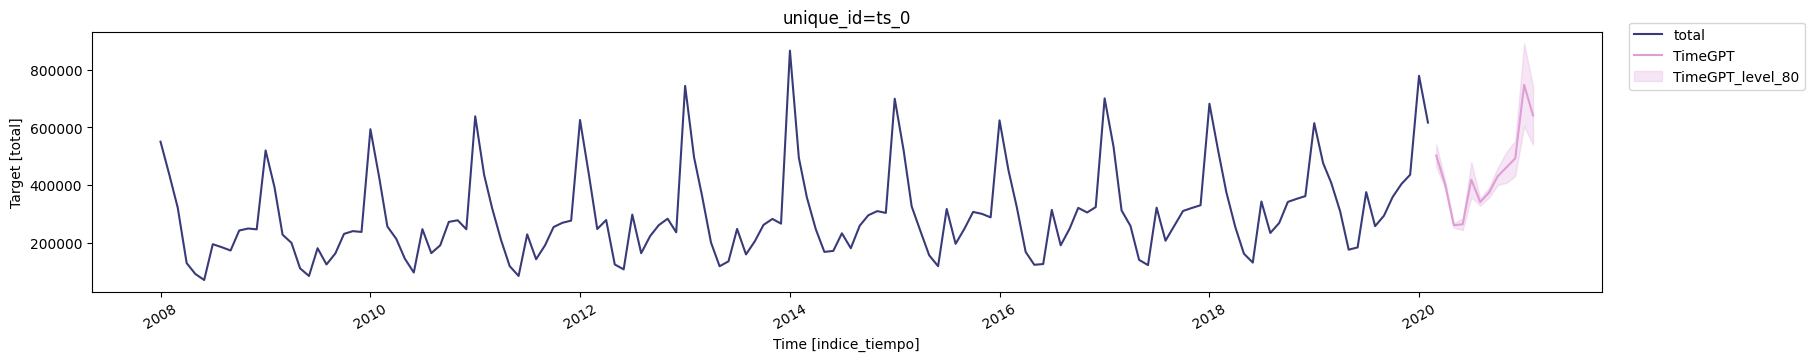

In [ ]:
# Pronosticos usando un 80 % de intervalos de confianza
forecast_df = nixtla_client.forecast(
    df=data,
    h=12,
    time_col='indice_tiempo',
    target_col="total",
    level=[80]
)


nixtla_client.plot(
    df=data,
    forecasts_df=forecast_df,
    time_col='indice_tiempo',
    target_col='total',
    level=[80]
)

# Parte final, para que ud practiquen.

A partir de la serie seleccionada se pide:

Preparar los datos en el formato requerido por el modelo., realizar un analisis exploratorio de la serie temporal, aplicar el modelo para generar predicciones a futuro, evaluar e interpretar los resultados obtenidos, discutir las decisiones tomadas durante el proceso.

Gracias!